# Часть 1 Бустинг (5 баллов)

В этой части будем предсказывать зарплату data scientist-ов в зависимости  от ряда факторов с помощью градиентного бустинга.

В датасете есть следующие признаки:



* work_year: The number of years of work experience in the field of data science.

* experience_level: The level of experience, such as Junior, Senior, or Lead.

* employment_type: The type of employment, such as Full-time or Contract.

* job_title: The specific job title or role, such as Data Analyst or Data Scientist.

* salary: The salary amount for the given job.

* salary_currency: The currency in which the salary is denoted.

* salary_in_usd: The equivalent salary amount converted to US dollars (USD) for comparison purposes.

* employee_residence: The country or region where the employee resides.

* remote_ratio: The percentage of remote work offered in the job.

* company_location: The location of the company or organization.

* company_size: The company's size is categorized as Small, Medium, or Large.

In [1]:
import pandas as pd

df = pd.read_csv("ds_salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


## Задание 1 (0.5 балла) Подготовка



*   Разделите выборку на train, val, test (80%, 10%, 10%)
*   Выдерите salary_in_usd в качестве таргета
*   Найдите и удалите признак, из-за которого возможен лик в данных


In [2]:
from sklearn.model_selection import train_test_split

y = df['salary_in_usd']
X = df.drop(columns=['salary_in_usd', 'salary'])  

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=42
)

X_train.shape, X_val.shape, X_test.shape

((3004, 9), (375, 9), (376, 9))

## Задание 2 (0.5 балла) Линейная модель


*   Закодируйте категориальные  признаки с помощью OneHotEncoder
*   Обучите модель линейной регрессии
*   Оцените  качество через MAPE и RMSE


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder
import numpy as np

categorical_features = X_train.select_dtypes(include='object').columns.tolist()
numeric_features = X_train.select_dtypes(exclude='object').columns.tolist()

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = ohe.fit_transform(X_train[categorical_features])
X_val_cat = ohe.transform(X_val[categorical_features])

X_train_new = np.hstack([X_train[numeric_features].values, X_train_cat])
X_val_new = np.hstack([X_val[numeric_features].values, X_val_cat])

model = LinearRegression()
model.fit(X_train_new, y_train)

pred = model.predict(X_val_new)


print('MAPE: ', mean_absolute_percentage_error(y_val, pred))
print('RMSE: ', np.sqrt(mean_squared_error(y_val, pred)))

MAPE:  0.43022855206127725
RMSE:  46842.078054970305


На валидационной выборке модель по MAPE = 0.43, то есть средняя относительная ошибка 43%. RMSE = 46 842, то есть среднее отклонение предсказанной зарплаты от фактической составляет примерно 47 тысяч долларов. Можно сказать, что качество предсказания умеренное

## Задание 3 (0.5 балла) XGboost

Начнем с библиотеки xgboost.

Обучите модель `XGBRegressor` на тех же данных, что линейную модель, подобрав оптимальные гиперпараметры (`max_depth, learning_rate, n_estimators, gamma`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [4]:
from xgboost.sklearn import XGBRegressor
import time

grid = []
best_rmse = 10**18
best_model = None
best_params = None

for d in [3, 4, 5]:
    for lr in [0.03, 0.05, 0.1]:
        for n in [100, 300, 500]:
            p = {
                'max_depth': d,
                'learning_rate': lr,
                'n_estimators': n,
                'gamma': 0,
                'random_state': 42,
                'objective': 'reg:squarederror'
            }

            m = XGBRegressor(**p)

            t0 = time.time()
            m.fit(X_train_new, y_train)
            tr_time = time.time() - t0

            t0 = time.time()
            pr = m.predict(X_val_new)
            pr_time = time.time() - t0

            mape = mean_absolute_percentage_error(y_val, pr)
            rmse = np.sqrt(mean_squared_error(y_val, pr))

            grid.append([d, lr, n, mape, rmse, tr_time, pr_time])

            if rmse < best_rmse:
                best_rmse = rmse
                best_model = m
                best_params = p
                pred_xgb = pr
                train_time = tr_time
                pred_time = pr_time

In [5]:
print('Best params:', best_params)
print('MAPE:', mean_absolute_percentage_error(y_val, pred_xgb))
print('RMSE:', np.sqrt(mean_squared_error(y_val, pred_xgb)))
print('Train time:', train_time)
print('Predict time:', pred_time)

Best params: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 500, 'gamma': 0, 'random_state': 42, 'objective': 'reg:squarederror'}
MAPE: 0.38784170150756836
RMSE: 45106.08863557114
Train time: 0.36487293243408203
Predict time: 0.0006151199340820312


In [6]:
pd.DataFrame(grid, columns=['max_depth', 'learning_rate', 'n_estimators', 'MAPE', 'RMSE', 'train_time', 'pred_time']).sort_values('RMSE')

,max_depth,learning_rate,n_estimators,MAPE,RMSE,train_time,pred_time
5,3,0.05,500,0.387842,45106.088636,0.364873,0.000615
2,3,0.03,500,0.392303,45127.066113,0.338305,0.000605
4,3,0.05,300,0.392756,45158.976073,0.205982,0.000564
8,3,0.10,500,0.382671,45215.145073,0.341328,0.000714
7,3,0.10,300,0.386354,45219.716762,0.205122,0.000531
22,5,0.05,300,0.383140,45412.593143,0.299556,0.000575
13,4,0.05,300,0.383644,45457.027795,0.250236,0.000694
11,4,0.03,500,0.384225,45490.839166,0.416297,0.000656
6,3,0.10,100,0.404213,45490.889813,0.075278,0.000424
14,4,0.05,500,0.380667,45497.496019,0.417162,0.000798


MAPE снизился с 43.0% до 38.4%
RMSE снизился с 46842 до 45106
Скорость обучения и предсказания хорошие, примерно 0.34 сек и предсказание примерно 0.001 сек. В общем, бустинг нашел такие нелинейные взаимодействия между признаками, которых не находила линейная регрессия

## Задание 4 (1 балл) CatBoost

Теперь библиотека CatBoost.

Обучите модель `CatBoostRegressor`, подобрав оптимальные гиперпараметры (`depth, learning_rate, iterations`, etc.) по валидационной выборке. Оцените качество итоговой модели (MAPE, RMSE), скорость обучения и скорость предсказания.

In [7]:
from catboost import CatBoostRegressor
import time

best_rmse = 10**18
best_model = None
best_params = None

for d in [4, 6, 8]:
    for lr in [0.03, 0.05, 0.1]:
        for it in [100, 300, 500]:

            params = {
                'depth': d,
                'learning_rate': lr,
                'iterations': it,
                'loss_function': 'RMSE',
                'random_seed': 42,
                'verbose': False
            }

            model = CatBoostRegressor(**params)

            t0 = time.time()
            model.fit(X_train_new, y_train)
            train_time = time.time() - t0

            t0 = time.time()
            pred = model.predict(X_val_new)
            pred_time = time.time() - t0

            mape = mean_absolute_percentage_error(y_val, pred)
            rmse = np.sqrt(mean_squared_error(y_val, pred))

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = params
                best_pred = pred
                best_train_time = train_time
                best_pred_time = pred_time

In [8]:
print('Best params:', best_params)
print('MAPE:', mean_absolute_percentage_error(y_val, best_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_val, best_pred)))
print('Train time:', best_train_time)
print('Predict time:', best_pred_time)

Best params: {'depth': 4, 'learning_rate': 0.1, 'iterations': 500, 'loss_function': 'RMSE', 'random_seed': 42, 'verbose': False}
MAPE: 0.3857561947220997
RMSE: 44838.51443153157
Train time: 0.13721418380737305
Predict time: 0.0005779266357421875


CatBoost был обучен на заранее закодированных признаках после One-Hot Encoding 
Лучшие параметры depth=4, learning_rate=0.1, iterations=500. 
Качество получилось MAPE примерно 0.386 и RMSE примерно 44839.

Для применения catboost моделей не обязательно сначала кодировать категориальные признаки, модель может кодировать их сама. Обучите catboost с подбором оптимальных гиперпараметров снова, используя pool для передачи данных в модель с указанием какие признаки категориальные, а какие нет с помощью параметра cat_features. Оцените качество и время. Стало ли лучше?

In [9]:
from catboost import Pool

cat_idx = [
    X_train.columns.get_loc(c)
    for c in categorical_features
]

train_pool = Pool(
    X_train,
    y_train,
    cat_features=cat_idx
)

val_pool = Pool(
    X_val,
    y_val,
    cat_features=cat_idx
)

In [10]:
best_rmse = 10**18

for d in [4, 6, 8]:
    for lr in [0.03, 0.05, 0.1]:
        for it in [100, 300, 500]:

            model = CatBoostRegressor(
                depth=d,
                learning_rate=lr,
                iterations=it,
                loss_function='RMSE',
                random_seed=42,
                verbose=False
            )

            t0 = time.time()
            model.fit(train_pool)
            train_time_pool = time.time() - t0

            t0 = time.time()
            pred_pool = model.predict(val_pool)
            pred_time_pool = time.time() - t0

            rmse = np.sqrt(mean_squared_error(y_val, pred_pool))

            if rmse < best_rmse:
                best_rmse = rmse
                best_model_pool = model
                best_pred_pool = pred_pool
                best_train_time_pool = train_time_pool
                best_pred_time_pool = pred_time_pool

In [11]:
print('MAPE:', mean_absolute_percentage_error(y_val, best_pred_pool))
print('RMSE:', np.sqrt(mean_squared_error(y_val, best_pred_pool)))
print('Train time:', best_train_time_pool)
print('Predict time:', best_pred_time_pool)

MAPE: 0.41956761416672833
RMSE: 45135.17692971342
Train time: 0.669597864151001
Predict time: 0.0004391670227050781


CatBoost был обучен на исходных данных через Pool с указанием категориальных признаков.
С Pool качество получилось хуже, MAPE примерно 0.420, а RMSE примерно 45135. 
При этом обучение через Pool заняло больше времени, около 0.63 секунд, а предсказание осталось таким же быстрым
Можно сказать, что в данном случае CatBoost с автоматической обработкой категориальных признаков через cat_features не улучшил качество. Лучший результат показал CatBoost на данных после One-Hot Encoding

## Задание 5 (0.5 балла) LightGBM

И наконец библиотека LightGBM - используйте `LGBMRegressor`, снова подберите гиперпараметры, оцените качество и скорость.


In [12]:
from lightgbm import LGBMRegressor
import time

best_rmse = 10**18

for d in [3, 4, 5, 6]:
    for lr in [0.03, 0.05, 0.1]:
        for n in [100, 300, 500]:

            params = {
                'max_depth': d,
                'learning_rate': lr,
                'n_estimators': n,
                'random_state': 42,
                'verbose': -1
            }

            model = LGBMRegressor(**params)

            t0 = time.time()
            model.fit(X_train_new, y_train)
            train_time_lgbm = time.time() - t0

            t0 = time.time()
            pred_lgbm = model.predict(X_val_new)
            pred_time_lgbm = time.time() - t0

            rmse = np.sqrt(mean_squared_error(y_val, pred_lgbm))

            if rmse < best_rmse:
                best_rmse = rmse
                best_params_lgbm = params
                best_pred_lgbm = pred_lgbm
                best_train_time_lgbm = train_time_lgbm
                best_pred_time_lgbm = pred_time_lgbm

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/skle

In [13]:
print('Best params:', best_params_lgbm)
print('MAPE:', mean_absolute_percentage_error(y_val, best_pred_lgbm))
print('RMSE:', np.sqrt(mean_squared_error(y_val, best_pred_lgbm)))
print('Train time:', best_train_time_lgbm)
print('Predict time:', best_pred_time_lgbm)

Best params: {'max_depth': 3, 'learning_rate': 0.03, 'n_estimators': 300, 'random_state': 42, 'verbose': -1}
MAPE: 0.4057769174021563
RMSE: 45826.91461357704
Train time: 0.2304549217224121
Predict time: 0.0011000633239746094


Лучшие параметры max_depth=3, learning_rate=0.03, n_estimators=300
Качество модели, MAPE примерно 0.406,а RMSE примерно 45826
Средняя относительная ошибка составляет около 40.6%, а средняя ошибка прогноза в зарплате примерно 45.8 тыс. долларов
Обучение заняло около 0.21 секунды, предсказание около 0.0012 секунды, то есть модель работает очень быстро

## Задание 6 (2 балла) Сравнение и выводы

Сравните модели бустинга и сделайте про них выводы, какая из моделей показала лучший/худший результат по качеству, скорости обучения и скорости предсказания? Как отличаются гиперпараметры для разных моделей?

In [42]:
res = pd.DataFrame({
    'Модель': ['Linear Regression', 'XGBoost', 'CatBoost (OHE)', 'CatBoost (Pool)', 'LightGBM'],
    'MAPE': [0.430, 0.388, 0.386, 0.420, 0.406],
    'RMSE': [46842, 45106, 44838, 45135, 45826],
    'Время обучения (с)': [None, 0.275, 0.137, 0.631, 0.214],
    'Время предсказания (с)': [None, 0.0023, 0.0005, 0.0004, 0.0012]
})

res

,Модель,MAPE,RMSE,Время обучения (с),Время предсказания (с)
0,Linear Regression,0.430,46842,NaN,NaN
1,XGBoost,0.388,45106,0.275,0.0023
2,CatBoost (OHE),0.386,44838,0.137,0.0005
3,CatBoost (Pool),0.420,45135,0.631,0.0004
4,LightGBM,0.406,45826,0.214,0.0012


**Ответ:** По результатам экспериментов лучшей моделью по качеству оказался CatBoost на данных после OHE. Он показал минимальное значение RMSE = 44838 и MAPE = 0.386
Эта модель обеспечивает наиболее точный прогноз заработной платы среди рассмотренных алгоритмов.

XGBoost дал RMSE = 45106 и MAPE = 0.388. Он уступил CatBoost, поэтому его качество можно считать немного ниже.
LightGBM показал средний результат RMSE = 45826, а MAPE = 0.406, это лучше линрега, но уступает CatBoost и XGBoost.
Худшее качество показала линейная регрессия с RMSE = 46842 и MAPE = 0.430, поскольку она способна моделировать только линейные зависимости между признаками и целевой переменной.

Можно заметить, что CatBoost с использованием Pool и автоматической обработкой категориальных признаков не улучшил качество по сравнению с вариантом после OHE. В данной задаче предварительное кодирование категориальных признаков оказалось более эффективным.

По скорости обучения быстрее всего обучился CatBoost на OHE 0.14 секундами, затем LightGBM = 0.21 секунда, затем XGBoost = 0.27 секунд.
Самым медленным оказался CatBoost с Pool = 0.63 секунды. Скорость предсказания у всех моделей очень высокая и сильно отличается.

К тому же, во всех лучших конфигурациях использовалась небольшая глубина деревьев и достаточно большое число деревьев или итераций

# Часть 2 Кластеризация (5 баллов)

Будем работать с данными о том, каких исполнителей слушают пользователи музыкального сервиса.

Каждая строка таблицы - информация об одном пользователе. Каждый столбец - это исполнитель (The Beatles, Radiohead, etc.)

Для каждой пары (пользователь, исполнитель) в таблице стоит число - доля прослушивания этого исполнителя этим пользователем.


In [15]:
ratings = pd.read_excel("https://github.com/evgpat/edu_stepik_rec_sys/blob/main/datasets/sample_matrix.xlsx?raw=true", engine='openpyxl')
ratings.head()

,user,the beatles,radiohead,deathcab for cutie,coldplay,modest mouse,sufjan stevens,dylan. bob,red hot clili peppers,pink fluid,...,municipal waste,townes van zandt,curtis mayfield,jewel,lamb,michal w. smith,群星,agalloch,meshuggah,yellowcard
0,0,NaN,0.020417,NaN,NaN,NaN,NaN,NaN,0.030496,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,NaN,0.184962,0.024561,NaN,NaN,0.136341,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,NaN,NaN,0.028635,NaN,NaN,NaN,0.024559,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,0.043529,0.086281,0.034590,0.016712,0.015935,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Будем строить кластеризацию исполнителей: если двух исполнителей слушало много людей примерно одинаковую долю своего времени (то есть векторы близки в пространстве), то, возможно исполнители похожи. Эта информация может быть полезна при построении рекомендательных систем.

## Задание 1 (0.5 балла) Подготовка

Транспонируем матрицу ratings, чтобы по строкам стояли исполнители.

In [16]:
ratings = ratings.T
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
user,0.000000,1.000000,2.000000,3.0,4.000000,5.000000,6.0,7.0,8.000000,9.000000,...,4990.000000,4991.0,4992.000000,4993.000000,4994.000000,4995.000000,4996.0,4997.000000,4998.0,4999.000000
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Выкиньте строку под названием `user`.

In [17]:
ratings = ratings.drop('user')
ratings.head()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
the beatles,NaN,NaN,NaN,NaN,0.043529,NaN,NaN,NaN,0.093398,0.017621,...,NaN,NaN,0.121169,0.038168,0.007939,0.017884,NaN,0.076923,NaN,NaN
radiohead,0.020417,0.184962,NaN,NaN,0.086281,0.006322,NaN,NaN,NaN,0.019156,...,0.017735,NaN,NaN,NaN,0.011187,NaN,NaN,NaN,NaN,NaN
deathcab for cutie,NaN,0.024561,0.028635,NaN,0.034590,NaN,NaN,NaN,NaN,0.013349,...,0.121344,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.027893
coldplay,NaN,NaN,NaN,NaN,0.016712,NaN,NaN,NaN,NaN,NaN,...,0.217175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modest mouse,NaN,NaN,NaN,NaN,0.015935,NaN,NaN,NaN,NaN,0.030437,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


В таблице много пропусков, так как пользователи слушают не всех-всех исполнителей, чья музыка представлена в сервисе, а некоторое подмножество (обычно около 30 исполнителей)


Доля исполнителя в музыке, прослушанной  пользователем, равна 0, если пользователь никогда не слушал музыку данного музыканта, поэтому заполните пропуски нулями.



In [19]:
ratings = ratings.fillna(0)
ratings.sample()

,0,1,2,3,4,5,6,7,8,9,...,4990,4991,4992,4993,4994,4995,4996,4997,4998,4999
from first to last,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Задание 2 (0.5 балла) Первая кластеризация

Примените KMeans с 5ю кластерами, сохраните полученные лейблы

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(ratings)

labels

array([4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 3, 3, 0, 0,
       0, 3, 0, 3, 3, 0, 0, 3, 0, 0, 0, 3, 0, 0, 0, 3, 3, 3, 0, 3, 0, 0,
       3, 3, 0, 0, 3, 3, 3, 0, 3, 0, 3, 3, 0, 3, 0, 3, 3, 0, 0, 3, 0, 0,
       0, 3, 3, 0, 3, 0, 3, 3, 0, 0, 3, 3, 3, 3, 3, 3, 0, 0, 0, 3, 0, 3,
       0, 3, 3, 3, 0, 0, 3, 3, 3, 0, 3, 0, 0, 3, 3, 0, 3, 0, 0, 3, 3, 3,
       3, 0, 3, 0, 0, 3, 3, 3, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 3,
       3, 0, 3, 3, 3, 0, 0, 0, 3, 3, 3, 3, 0, 0, 3, 3, 0, 3, 0, 3, 3, 3,
       0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 0, 3, 3, 0, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 3, 3, 3, 0,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,

Выведите размеры кластеров. Полезной ли получилась кластеризация? Почему KMeans может выдать такой результат?

In [21]:
pd.Series(labels).value_counts().sort_index()

0    115
1      1
2      1
3    882
4      1
Name: count, dtype: int64

**Ответ:** Размеры кластеров получились неравномерными. В кластере 3 получилось 882 исполнителя, в кластере 0 их 115 исполнителей, тогда как в кластерах 1, 2 и 4 только по одному исполнителю.

Такая кластеризация не очень полезна, так как KMeans фактически выделил несколько отдельных выбросов, а большинство исполнителей объединил в один большой кластер. Возможно это произошло из-за разреженности данных, большинство пользователей не слушали большинство исполнителей, поэтому в матрице очень много нулей. Из-за этого исполнители становятся похожими по отсутствию прослушиваний, а не по реальному сходству аудитории.

## Задание 3 (0.5 балла) Объяснение результатов

При кластеризации получилось $\geq 1$ кластера размера 1. Выведите исполнителей, которые составляют такие кластеры. Среди них должна быть группа The Beatles.

In [22]:
small = ratings.index[pd.Series(labels, index=ratings.index).map(
    pd.Series(labels).value_counts()
) == 1]

small

Index(['the beatles', 'niИ', '日dir en grey'], dtype='object')

Изучите данные, почему именно The Beatles выделяется?

Подсказка: посмотрите на долю пользователей, которые слушают каждого исполнителя, среднюю долю прослушивания.

In [23]:
stats = pd.DataFrame({
    'listeners_share': (ratings > 0).mean(axis=1),
    'mean_listen_share': ratings.mean(axis=1)
})

stats.loc[small]

,listeners_share,mean_listen_share
the beatles,0.3342,0.018369
niИ,0.1182,0.006470
日dir en grey,0.0102,0.001689


**Ответ:** В кластеры размера 1 попали `the beatles`, `niИ` и `日dir en grey`.
The Beatles выделяется сильнее всего, так как их слушали 33.42% пользователей, а средняя доля прослушиваний = 0.0184. Это заметно больше, чем у других исполнителей из маленьких кластеров.

Доля пользователей показывает, насколько исполнитель массовый, по сути сколько пользователей вообще его когда-то слушали. Средняя доля прослушивания показывает, какую часть времени в среднем пользователи отдавали этому исполнителю. 
А The Beatles выделяется, потому что их слушает очень большая доля пользователей. Для KMeans такой исполнитель оказывается отдельным объектом, поскольку он слишком отличается от большинства менее популярных исполнителей.

## Задание 4 (0.5 балла) Улучшение кластеризации

Попытаемся избавиться от этой проблемы: нормализуйте данные при помощи `normalize`.

In [24]:
from sklearn.preprocessing import normalize

ratings_norm = normalize(ratings)

Примените KMeans с 5ю кластерами на преобразованной матрице, посмотрите на их размеры. Стало ли лучше? Может ли кластеризация быть полезной теперь?

In [25]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_norm = km.fit_predict(ratings_norm)

pd.Series(labels_norm).value_counts().sort_index()

0     79
1    162
2    133
3    140
4    486
Name: count, dtype: int64

**Ответ** После нормализации видно, что размеры кластеров стали более сбалансированными. Теперь нет кластеров размера 1.

Самый большой кластер все еще заметно больше остальных: в нем 486 исполнителей. Но остальные кластеры тоже содержат достаточно много исполнителей: 79, 162, 133 и 140.

Кластеризация теперь может быть полезной, так как модель меньше ориентируется на общую популярность исполнителя и больше учитывает структуру прослушиваний, то есть какие пользователи слушают похожих исполнителей.

## Задание 5 (1 балл) Центроиды

Выведите для каждого кластера названия топ-10 исполнителей, ближайших к центроиду по косинусной мере. Проинтерпретируйте результат. Что можно сказать о смысле кластеров?

In [26]:
from scipy.spatial.distance import cosine

centroids = km.cluster_centers_

for i in range(5):
    d = [cosine(ratings_norm[j], centroids[i]) for j in range(len(ratings))]
    top = pd.Series(d, index=ratings.index).sort_values().head(10)
    print(f'Кластер {i}:')
    print(list(top.index))
    print()

Кластер 0:
['nas', 'jay-z', 'kanye west', 'lupe the gorilla', 'a tribe called quest', "the roots featuring d'angelo", 'gangstarr', 'little brother', "lil' wayne", 'murs and 9th wonder']

Кластер 1:
['fall out boy', 'the all-americian rejects', 'paramore', 'kelly clarkson', 'john mayer', 'the fray', 'maroon5', 'dashboard confesssional', 'somethings corporate', 'coldplay']

Кластер 2:
['brand new', 'blink-182', 'alkaline trio', 'against me!', 'underoath', 'descendents', 'new found glory', 'less than jake', 'thrice', 'chiodos']

Кластер 3:
['the beatles', 'the rolling stones', 'dylan. bob', 'who', 'led zeppelin.', 'miles davis.', 'simon and garfunkel', 'young, neil', 'pink fluid', 'velvet underground']

Кластер 4:
['radiohead', 'the arcade fire', 'the shins', 'sufjan stevens', 'belle and sebastian', 'broken social scene', 'the pixies', 'animal collective', 'modest mouse', 'spoon']



**Ответ:** После нормализации кластеры стали отражать музыкальные вкусы и близость аудиторий, а не просто популярность исполнителей. Теперь кластеризация уже выглядит полезной для рекомендательной системы.

Кластер 0 это рэп: Nas, Jay-Z, Kanye West, Gang Starr.

Кластер 1 примерно поп-рок: Fall Out Boy, Paramore, Kelly Clarkson, Maroon 5, Coldplay.

Кластер 2 это панк или альтернативный рок: Blink-182, Alkaline Trio, Against Me!, New Found Glory.

Кластер 3 это классический рок или легендарные исполнители: The Beatles, The Rolling Stones, Led Zeppelin, Pink Floyd.

Кластер 4 это скорее инди музыка: Radiohead, Arcade Fire, Sufjan Stevens, Pixies, Modest Mouse.


## Задание 6 (1 балл) Визуализация

Хотелось бы как-то визуализировать полученную кластеризацию. Постройте точечные графики `plt.scatter` для нескольких пар признаков исполнителей, покрасив точки в цвета кластеров. Почему визуализации получились такими? Хорошо ли они отражают разделение на кластеры? Почему?

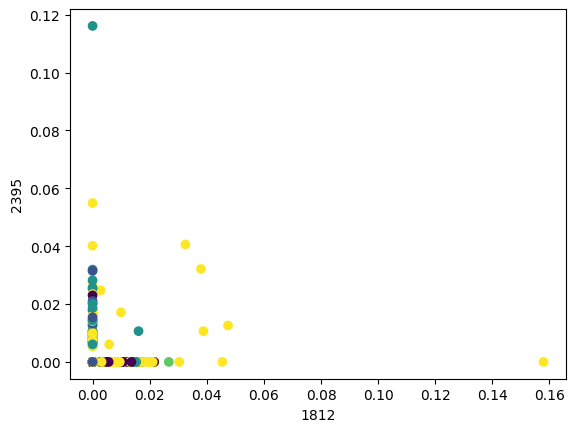

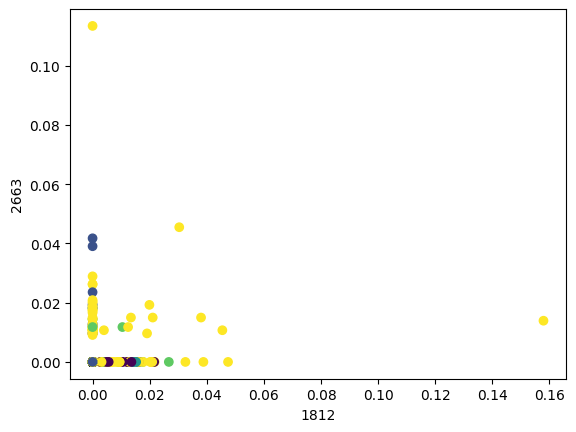

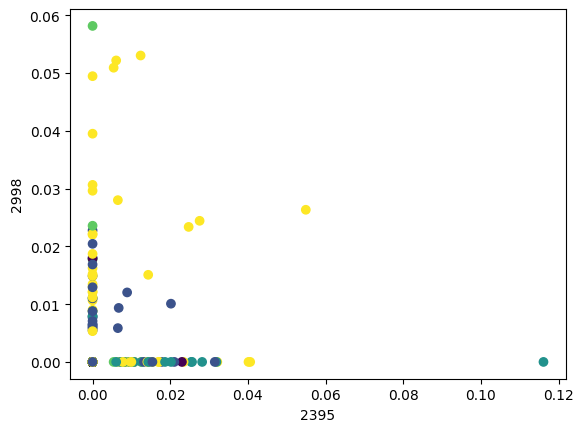

In [40]:
import matplotlib.pyplot as plt

cols = (ratings > 0).sum().sort_values(ascending=False).head(4).index

plt.scatter(ratings[cols[0]], ratings[cols[1]], c=labels_norm)
plt.xlabel(cols[0])
plt.ylabel(cols[1])
plt.show()

plt.scatter(ratings[cols[0]], ratings[cols[2]], c=labels_norm)
plt.xlabel(cols[0])
plt.ylabel(cols[2])
plt.show()

plt.scatter(ratings[cols[1]], ratings[cols[3]], c=labels_norm)
plt.xlabel(cols[1])
plt.ylabel(cols[3])
plt.show()

**Ответ:** На обычных двумерных scatter графиках явного разделения на кластеры не видно. Это связано с тем, что каждый исполнитель описывается 5000 признаками, а на каждом графике мы рассматриваем только два признака-пользователя. Поэтому большая часть информации теряется.

Большинство точек сосредоточено около нуля, так как матрица разреженная, многие пользователи не слушали многих исполнителей. Поэтому обычные двумерные проекции плохо отражают структуру кластеров.

Для визуализации данных высокой размерности существует метод t-SNE (стохастическое вложение соседей с t-распределением). Данный метод является нелинейным методом снижения размерности: каждый объект высокой размерности будет моделироваться объектов более низкой (например, 2) размерности таким образом, чтобы похожие объекты моделировались близкими, непохожие - далекими с большой вероятностью.

Примените `TSNE` из библиотеки `sklearn` и визуализируйте полученные объекты, покрасив их в цвета их кластеров

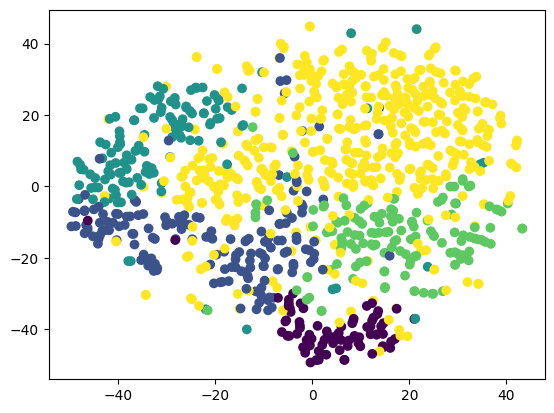

In [31]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, init='random', learning_rate='auto')
xy = tsne.fit_transform(ratings_norm)

plt.scatter(xy[:, 0], xy[:, 1], c=labels_norm)
plt.show()

После применения t-SNE видно, что исполнители образуют несколько групп. Некоторые кластеры хорошо отделены друг от друга, а другие частично пересекаются.
По сути кластеризация выявила реальные группы исполнителей со схожей аудиторией. При этом пересечения между кластерами ожидаемы, поскольку музыкальные предпочтения пользователей могут охватывать несколько жанров одновременно.

Можно сказать, что по визуализации видно, как после нормализации кластеризация стала содержательной и отражает сходство музыкальных предпочтений пользователей.

## Задание 7 (1 балл) Подбор гиперпараметров

Подберите оптимальное количество кластеров (максимум 100 кластеров) с использованием индекса Силуэта. Зафиксируйте `random_state=42`

In [34]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 101):
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab_k = km_k.fit_predict(ratings_norm)
    score = silhouette_score(ratings_norm, lab_k)
    scores.append((k, score))

scores = pd.DataFrame(scores, columns=['k', 'silhouette'])

scores.sort_values('silhouette', ascending=False).head(10)

,k,silhouette
82,84,0.013905
85,87,0.013825
97,99,0.013681
94,96,0.013590
91,93,0.013569
92,94,0.013526
84,86,0.013447
93,95,0.013422
96,98,0.013397
88,90,0.013382


In [35]:
best_k = scores.loc[scores['silhouette'].idxmax(), 'k']
best_k

np.int64(84)

Выведите исполнителей, ближайших с центроидам (аналогично заданию 5). Как соотносятся результаты? Остался ли смысл кластеров прежним? Расскажите про смысл 1-2 интересных кластеров, если он изменился и кластеров слишком много, чтобы рассказать про все.

In [36]:
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_best = km_best.fit_predict(ratings_norm)

centroids_best = km_best.cluster_centers_

for i in range(best_k):
    d = [cosine(ratings_norm[j], centroids_best[i]) for j in range(len(ratings))]
    top = pd.Series(d, index=ratings.index).sort_values().head(10)
    print(f'Кластер {i}:')
    print(list(top.index))
    print()

Кластер 0:
['raekwon', 'wu-tang clan', 'gza/genius', 'ghostface killah', 'mobb deep', 'cypress hill', 'nas', 'gangstarr', 'jay-z', 'a tribe called quest']

Кластер 1:
['she wants revenge', 'shiny toy guns', 'the bravery', 'pink*', 'mika', 'three days grase', 'placebo', 'frou frou', 'digitalism', 'the dandy warhols']

Кластер 2:
['vampire weekend', 'mgmt', 'girl talk', 'the go! team', 'the blow', 'dr. dog', 'bishop allen', 'the dodos', 'of montreal', 'the shins']

Кластер 3:
['the flaming lips', 'the apples in stereo', 'elvis costello and the attractions', 'grandaddy', 'the notwist', 'sparklehorse', 'orbital', 'elvis costello', 'sigur rós', 'm. ward']

Кластер 4:
['the smashing pumpkins', 'vnv nation', 'the blood brothers', 'moby', 'the pillows', 'niИ', 'system of a down', 'rammstein', 'radiohead', 'air']

Кластер 5:
['all time low', 'mayday parade', 'forever the sickest kids', 'fall out boy', 'cute is what we aim for', 'the academy is...', 'cobra starship', 'paramore', 'the spill canva

**Ответ:** Оптимальное число кластеров по индексу Силуэта = 84. Хотя значение silhouette очень маленькое, примерно 0.014, поэтому такое число кластеров нельзя считать однозначно лучшим. Скорее, данные имеют сложную структуру без очень четких границ между группами.

По сравнению с разбиением на 5 кластеров смысл в целом сохранился, то есть исполнители по-прежнему объединяются по похожим музыкальным вкусам аудитории. Но теперь крупные жанровые группы разбились на более мелкие поджанры и сцены.

Например, кластер 7 хорошо интерпретируется как heavy metal или classic metal (Iron Maiden, Megadeth...AC/DC). Это более узкий и понятный кластер, чем просто любой рок.

Кластер 6 похож на популярный рэп (Kanye West, Jay-Z...Drake, Chris Brown, Nas). Он близок по смыслу к рэп-кластеру из задания 5, но стал более конкретным.

Можно сказать, что при большом числе кластеров результат становится детальнее, то есть вместо 5 крупных музыкальных направлений модель выделяет много маленьких поджанров. Это может быть полезно для рекомендаций, хотя конечно проинтерпретировать все 84 кластера тяжело

Сделайте t-SNE визуализацию полученной кластеризации.

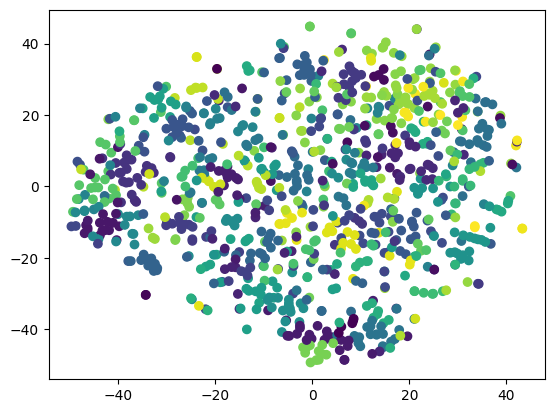

In [37]:
xy_best = TSNE(n_components=2, random_state=42, init='random', learning_rate='auto').fit_transform(ratings_norm)

plt.scatter(xy_best[:, 0], xy_best[:, 1], c=labels_best)
plt.show()

Если кластеров получилось слишком много и визуально цвета плохо отличаются, покрасьте только какой-нибудь интересный кластер из задания выше (`c = (labels == i)`). Хорошо ли этот кластер отражается в визуализации?

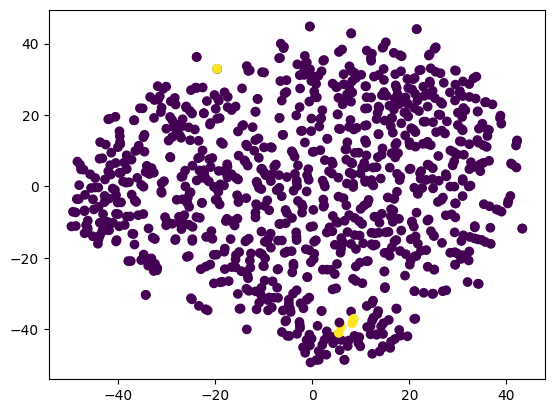

In [38]:
i = 0

plt.scatter(xy_best[:, 0], xy_best[:, 1], c=(labels_best == i))
plt.show()

**Ответ:** На t-SNE с 84 кластерами цвета различаются хуже, потому что кластеров слишком много. Визуально точки разных цветов сильно перемешаны, поэтому по общей картинке сложно интерпретировать все кластеры по отдельности сразу.

Отдельно выбранный кластер 0 в основном отображается компактно в нижней части графика, но один исполнитель  Cypress Hill оказался отдельно выше остальных. Это показывает, что внутри кластера есть пограничный объект. В исходном пространстве KMeans относит его к рэп-кластеру, но при снижении размерности t-SNE он визуально отделяется от основной группы.

При этом из-за очень маленького silhouette score около 0.014 нельзя сказать, что разбиение на 84 кластера идеально. Скорее, модель выделила много мелких музыкальных подгрупп, но границы между ними не очень четкие.


In [39]:
cluster0 = ratings.index[labels_best == 0]

pd.DataFrame({
    'artist': cluster0,
    'x': xy_best[labels_best == 0, 0],
    'y': xy_best[labels_best == 0, 1]
}).sort_values('y', ascending=False).head()

,artist,x,y
4,cypress hill,-19.613338,32.912144
2,gza/genius,8.535938,-37.047523
5,raekwon,8.436330,-37.603748
1,wu-tang clan,8.245079,-38.300449
0,ghostface killah,6.001814,-39.249821


Я решила проверить кто этот 1 отлетевший вверх желтый кружок. Всё норм, это Cypress Hill, и в исходном пространстве (5000 пользователей) KMeans считает Cypress Hill достаточно похожим на Wu-Tang Clan, GZA, Raekwon, Ghostface Killah..., поэтому помещает его в тот же кластер.
Но t-SNE при сжатии из 5000 измерений в 2 измерения не может идеально сохранить все расстояния. Он старается сохранить локальное соседство большинства объектов, но отдельные точки иногда вот так, как мы видим отлетают далеко от своей группы.